**Decision Tree Classification -- End to End with the Adult Income Dataset**

**The dataset.** : *Adult Income* dataset from the US Census. The task: predict whether a person earns more than \$50,000 a year (`>50K`) or not (`<=50K`).

In [1]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [2]:
df = pd.read_csv("phpMawTba.csv", na_values=['?', ' ?'], skipinitialspace=True)


In [3]:
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loaded 48,842 rows and 15 columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  class           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

In [6]:
df.describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


In [7]:
class_counts = df['class'].value_counts(dropna=False)
class_pct    = df['class'].value_counts(normalize=True).round(3) * 100

print("Class distribution:")
for cls in class_counts.index:
    print(f"  {cls!s:>8s} : {class_counts[cls]:>6,} ({class_pct[cls]:.1f}%)")

Class distribution:
     <=50K : 37,155 (76.1%)
      >50K : 11,687 (23.9%)


EDA

C:\Users\MSII\AppData\Local\Temp\ipykernel_15208\1058188571.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette=['steelblue', 'tomato'], ax=ax)


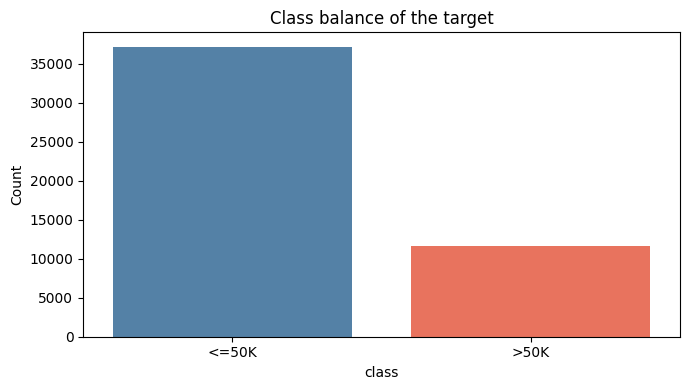

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='class', palette=['steelblue', 'tomato'], ax=ax)
ax.set_title('Class balance of the target')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

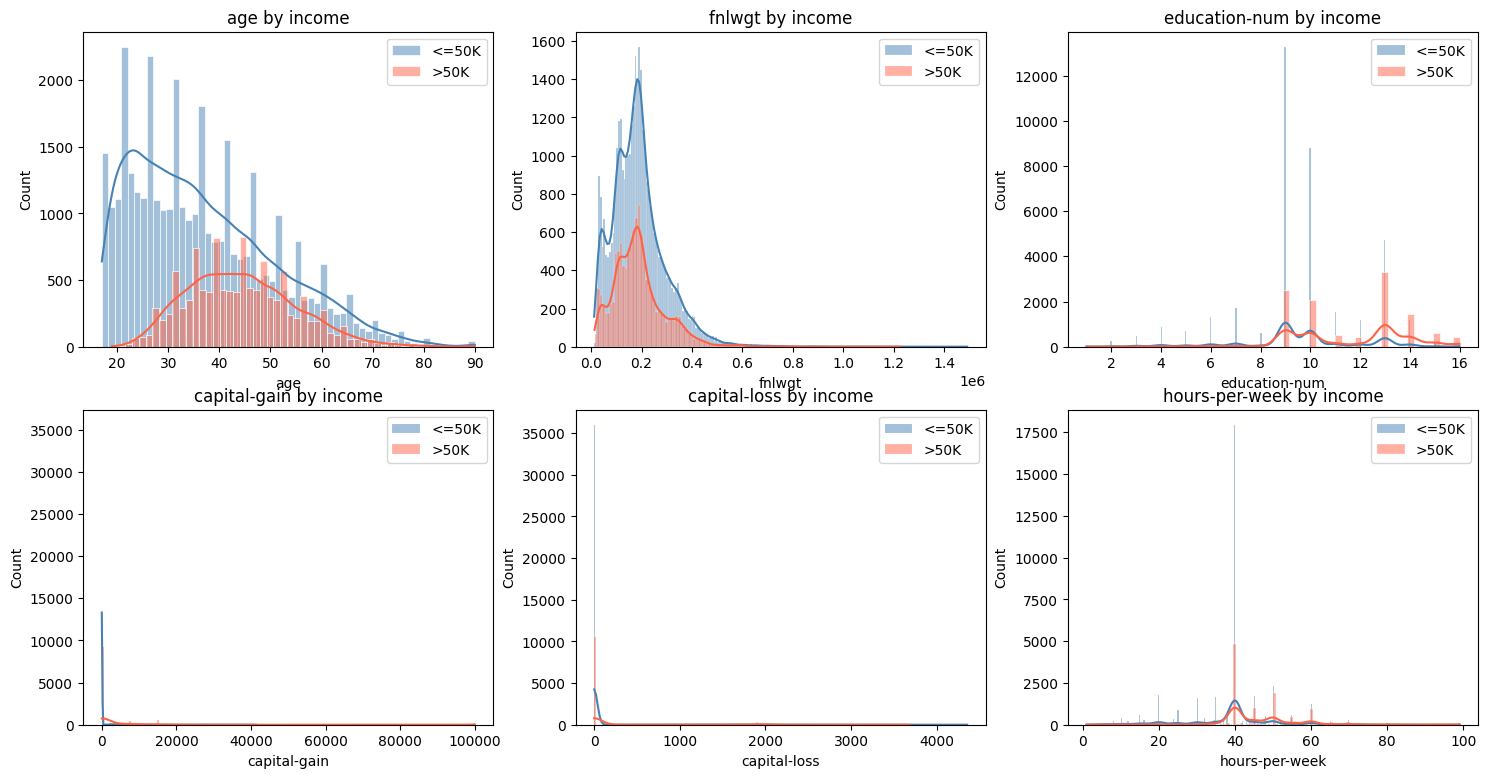

In [9]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), numeric_cols):
    for label, color in [('<=50K', 'steelblue'), ('>50K', 'tomato')]:
        sns.histplot(df[df['class'] == label][col], kde=True, ax=ax,color=color, edgecolor='white', alpha=0.5, label=label)
    ax.set_title(f'{col} by income')
    ax.set_xlabel(col)
    ax.legend()
# plt.tight_layout()
plt.show()

C:\Users\MSII\AppData\Local\Temp\ipykernel_15208\3665324731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=col, palette=['steelblue', 'tomato'], ax=ax)
C:\Users\MSII\AppData\Local\Temp\ipykernel_15208\3665324731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=col, palette=['steelblue', 'tomato'], ax=ax)
C:\Users\MSII\AppData\Local\Temp\ipykernel_15208\3665324731.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class', y=col, palette=['steelblue', 'tomato'], ax=ax)
C:\Users\M

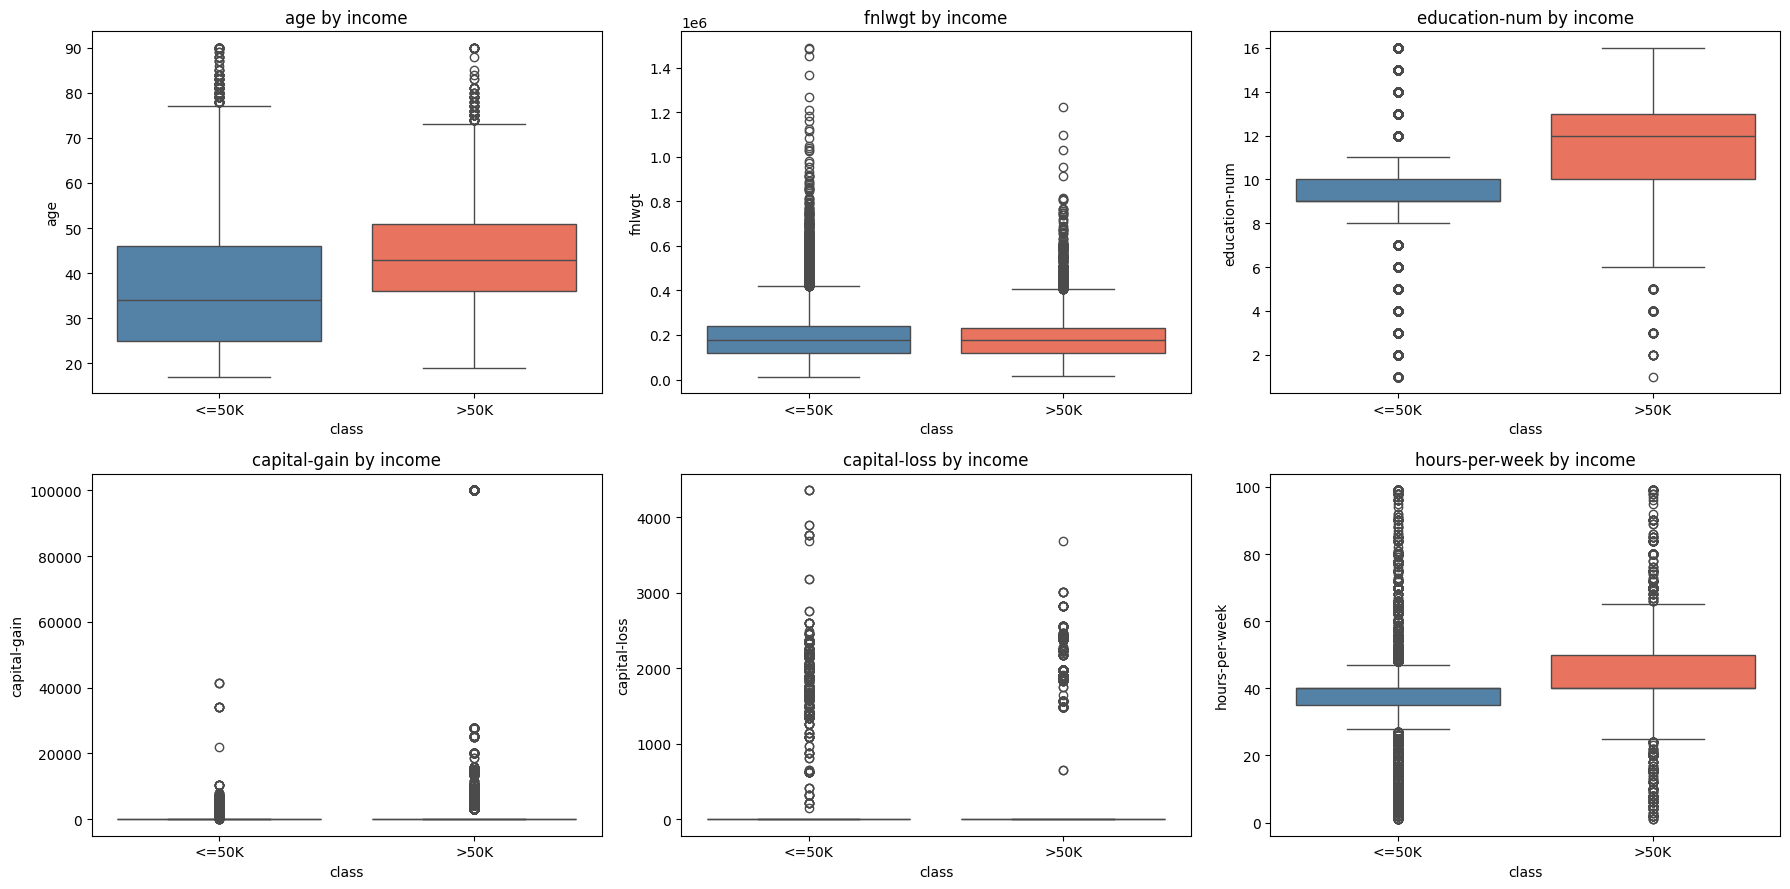

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(data=df, x='class', y=col, palette=['steelblue', 'tomato'], ax=ax)
    ax.set_title(f'{col} by income')
plt.tight_layout()
plt.show()

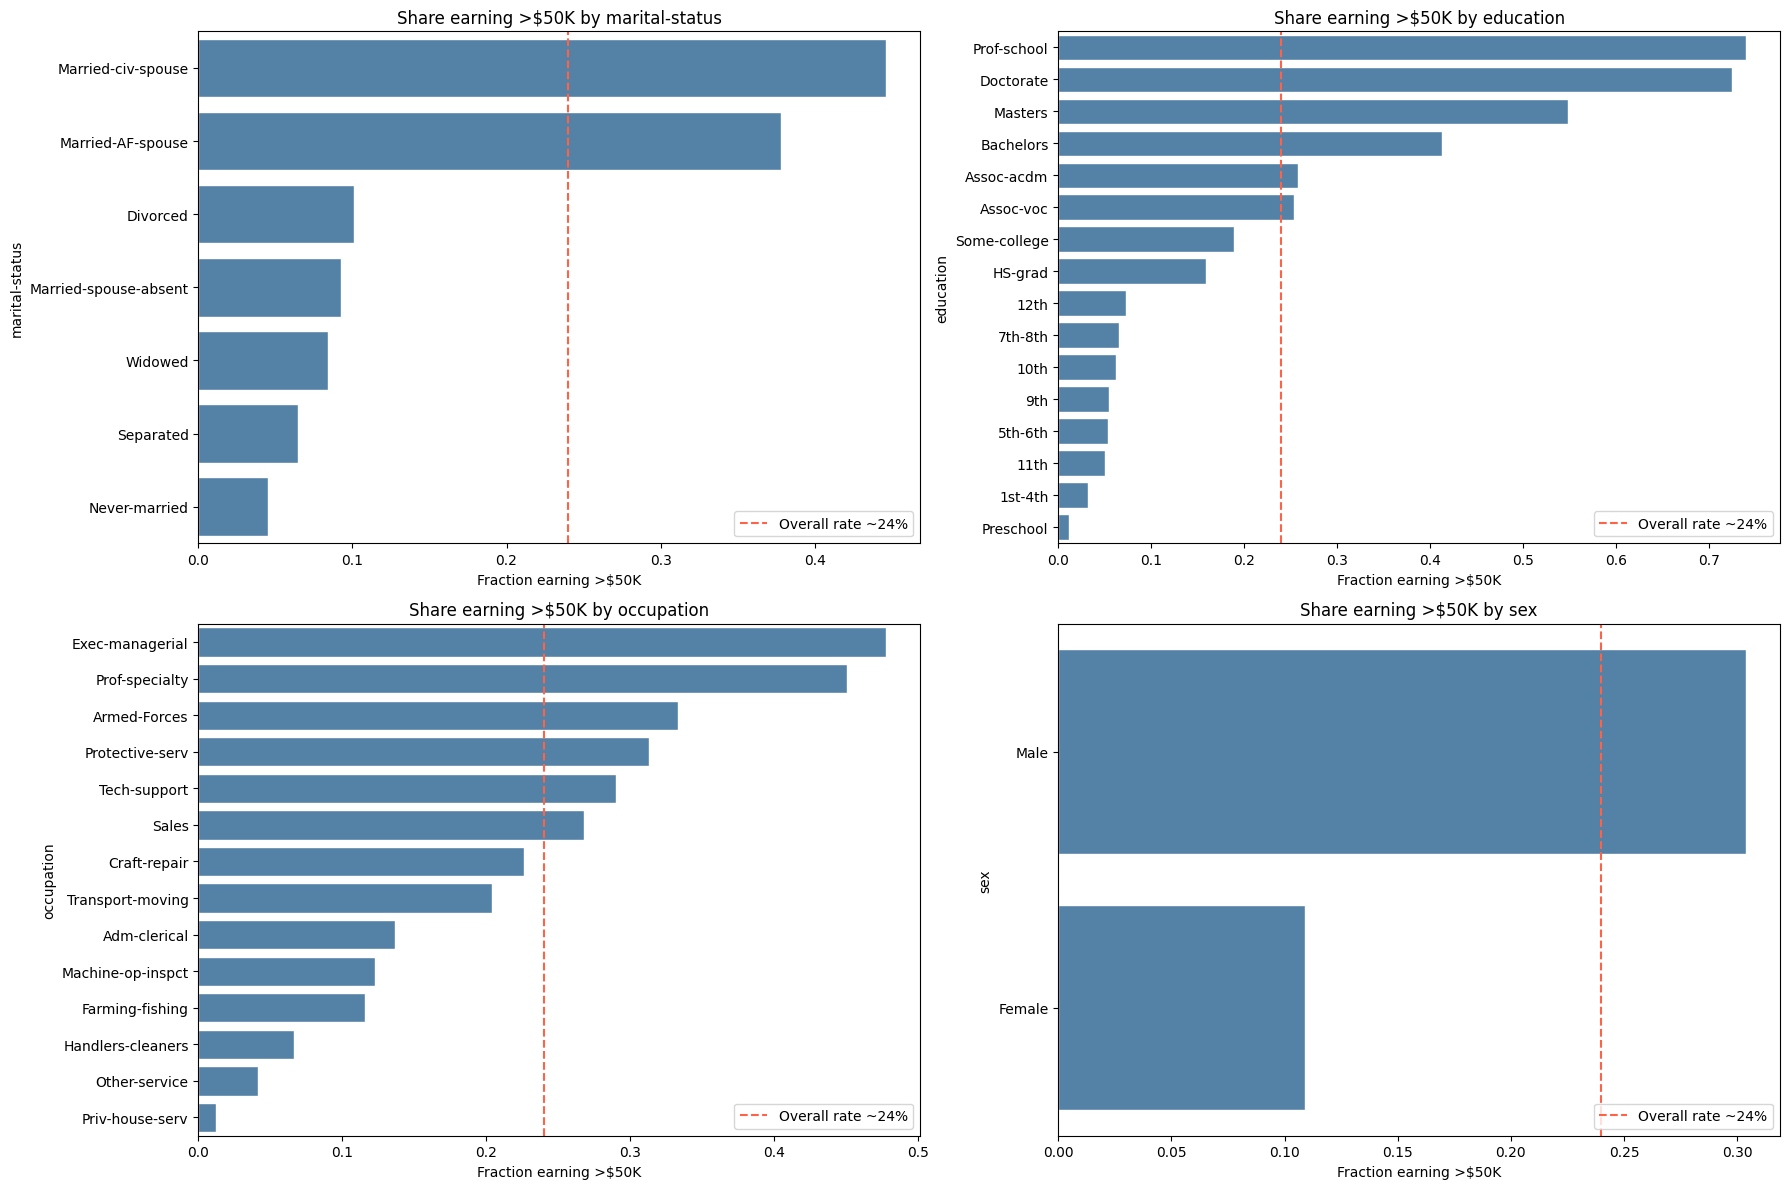

In [11]:
# the four categorical features we'd expect to matter most, based on intuition
quick_cats = ['marital-status', 'education', 'occupation', 'sex']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col in zip(axes.ravel(), quick_cats):
    rate = (df.assign(high=(df['class'] == '>50K').astype(int))
            .groupby(col)['high'].mean()
            .sort_values(ascending=False))
    sns.barplot(x=rate.values, y=rate.index, color='steelblue', ax=ax, edgecolor='white')
    ax.axvline(0.24, color='tomato', linestyle='--', linewidth=1.5, label='Overall rate ~24%')
    ax.set_title(f'Share earning >$50K by {col}')
    ax.set_xlabel('Fraction earning >$50K')
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

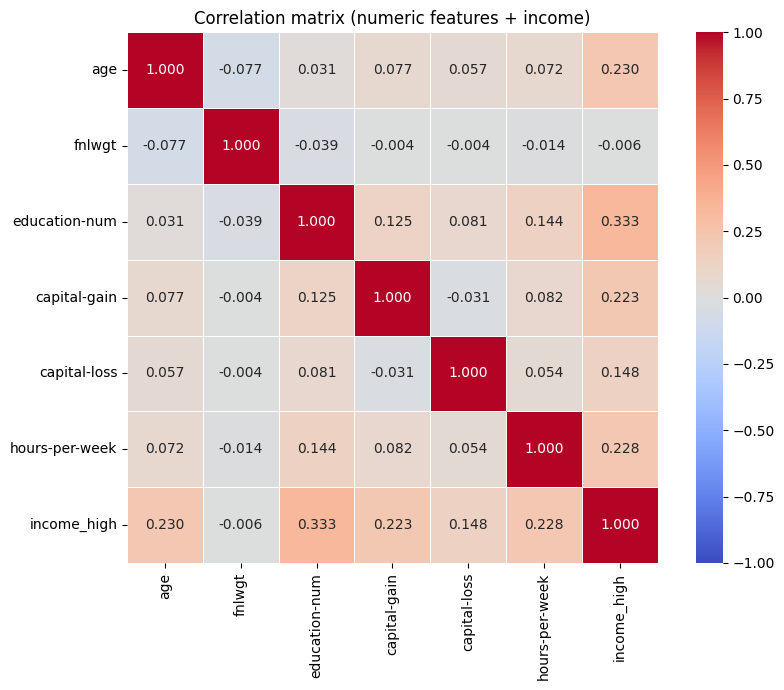

In [12]:
df_corr = df.copy()
df_corr['income_high'] = (df_corr['class'] == '>50K').astype(int)
corr = df_corr[numeric_cols + ['income_high']].corr().round(3)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, fmt='.3f', square=True)
plt.title('Correlation matrix (numeric features + income)')
plt.tight_layout()
plt.show()

In [13]:
before = df.shape[0]
df_clean = df.dropna().reset_index(drop=True)
print(f"Before: {before:,} rows  ->  After dropna: {df_clean.shape[0]:,} rows  ({(1 - df_clean.shape[0]/before)*100:.1f}% dropped)")

Before: 48,842 rows  ->  After dropna: 45,222 rows  (7.4% dropped)


In [14]:
df_clean['class'] = (df_clean['class'].str.strip() == '>50K').astype(int)
print("Target now binary (1 = >$50K):")
print(df_clean['class'].value_counts().to_dict())

Target now binary (1 = >$50K):
{0: 34014, 1: 11208}


In [15]:
df_clean.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


In [16]:
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']

df_enc = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)

# get_dummies produces bool columns -- cast to int so they play nicely with sklearn
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print(f"After one-hot encoding: {df_enc.shape[0]:,} rows x {df_enc.shape[1]:,} columns")
print(f"(Was {df_clean.shape[1]} columns; gained {df_enc.shape[1] - df_clean.shape[1]} from one-hot)")

After one-hot encoding: 45,222 rows x 105 columns
(Was 15 columns; gained 90 from one-hot)


### 5.4 Train/test split (stratified)

We hold out 30% of the data for testing, and pass `stratify=y` so the 76/24 class balance is preserved on both sides of the split. Because we're not scaling, there's nothing for the test set to leak into -- but the train/test discipline still matters for honest evaluation, and *especially* for trees, which overfit eagerly.

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from sklearn.preprocessing import StandardScaler


In [18]:
y = df_enc['class']
X = df_enc.drop("class", axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Number of features: {X.shape[1]}")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  class balance: {y_test.value_counts(normalize=True).round(3).to_dict()}")

Training set : 31,655 samples
Test set     : 13,567 samples
Number of features: 104
Train class balance: {0: 0.752, 1: 0.248}
Test  class balance: {0: 0.752, 1: 0.248}


In [19]:
scale = StandardScaler()
X_train_scale = X_train.copy()
X_test_scale = X_test.copy()
X_train_scale[numeric_cols] = scale.fit_transform(X_train[numeric_cols])
X_test_scale[numeric_cols] = scale.transform(X_test[numeric_cols])

In [20]:
from sklearn.tree import DecisionTreeClassifier


In [21]:
df_enc.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,class,workclass_Federal-gov,workclass_Local-gov,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,38,89814,9,0,0,50,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,28,336951,12,0,0,40,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,44,160323,10,7688,0,40,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,34,198693,6,0,0,30,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
